# Day 14: Adapting Models to Changing Constraints — Robustness and Feature Removal

Welcome to Day 14 of the **60-Day Data Science Challenge**! 📈

Today's sprint review introduces a major real-world challenge: **unexpected constraint shifts**. In industrial data science, datasets are rarely static. A feature that was once highly predictive can suddenly disappear due to:
- **Data Privacy Regulations**: dropping location features, PII, or browser cookies.
- **Sensor Failures / API Deprecations**: a hardware sensor breaks or a third-party service stops feeding a key feature.
- **Operational Shifts**: changes in business flow make a feature obsolete or unavailable at prediction time.

Yesterday (Day 13), we built regularized regression models and discovered that **`Is_Weekend`** was our single most important feature ( Lasso coefficient of **-38.42**). Today, we will:
1. **Drop `Is_Weekend`** from our feature set to simulate a sudden constraint shift.
2. **Retrain** our baseline OLS, Ridge, and Lasso models on the new restricted dataset.
3. **Compare performance** before vs. after to measure the degradation.
4. **Analyze adaptation**: examine how regularized coefficients shift and redistribute weight to the remaining features.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set styling for professional visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

### 1. Ingest the Dataset
We load our engineered transactions dataset from Day 10 (`engineered_store_transactions.csv`).

In [2]:
# Load dataset
df = pd.read_csv('../day10/engineered_store_transactions.csv')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset shape: 954 rows, 29 columns.


### 2. Establish baseline (With `Is_Weekend`) from Day 13
Let's split the dataset using the exact same criteria as yesterday (80/20 split, `random_state=42`) and fit the Lasso ($\alpha=5$) and Ridge ($\alpha=100$) models. This allows us to compare before/after performance directly.

In [3]:
y = df['Sales']
leakage_cols = [
    'Row ID', 'Order ID', 'Order Date', 'Customer Name', 
    'Sales', 'Sales_log', 'Sales_log_scaled', 
    'Sales_per_Unit', 'Sales_per_Unit_log', 'Sales_per_Unit_log_scaled',
    'Quantity', 'Order_Month', 'Order_Year', 'Order_DayOfWeek'
]
feature_cols_orig = [col for col in df.columns if col not in leakage_cols]

X_orig = df[feature_cols_orig]
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_orig, y, test_size=0.20, random_state=42
)

# Fit original models to verify baseline metrics
ols_orig = LinearRegression().fit(X_train_orig, y_train)
ridge_orig = Ridge(alpha=100.0, random_state=42).fit(X_train_orig, y_train)
lasso_orig = Lasso(alpha=5.0, max_iter=10000, random_state=42).fit(X_train_orig, y_train)

print("Original models fitted successfully!")

Original models fitted successfully!


### 3. Simulate the Constraint Shift: Dropping `Is_Weekend`
We drop `Is_Weekend` from our training and testing data and define the new restricted feature space. We train our models on the remaining 14 features.

In [4]:
feature_cols_new = [col for col in feature_cols_orig if col != 'Is_Weekend']
print(f"Original features: {len(feature_cols_orig)}")
print(f"New features:      {len(feature_cols_new)}")
print("\nRemaining feature set:", feature_cols_new)

X_new = df[feature_cols_new]
X_train_new, X_test_new, y_train, y_test = train_test_split(
    X_new, y, test_size=0.20, random_state=42
)

Original features: 15
New features:      14

Remaining feature set: ['Segment_Consumer', 'Segment_Corporate', 'Segment_Home Office', 'Category_Furniture', 'Category_Office Supplies', 'Category_Technology', 'Zip_02108', 'Zip_10008', 'Zip_60610', 'Zip_77041', 'Zip_90036', 'Zip_Unknown', 'Quantity_scaled', 'Order_Month_scaled']


### 4. Retrain Models on the New Restricted Feature Space
Let's retrain standard OLS, Ridge ($\alpha=100$), and Lasso ($\alpha=5$) on the new dataset.

In [5]:
# OLS New
ols_new = LinearRegression()
ols_new.fit(X_train_new, y_train)
y_train_pred_ols = ols_new.predict(X_train_new)
y_test_pred_ols = ols_new.predict(X_test_new)

# Ridge New (alpha=100)
ridge_new = Ridge(alpha=100.0, random_state=42)
ridge_new.fit(X_train_new, y_train)
y_train_pred_ridge = ridge_new.predict(X_train_new)
y_test_pred_ridge = ridge_new.predict(X_test_new)

# Lasso New (alpha=5)
lasso_new = Lasso(alpha=5.0, max_iter=10000, random_state=42)
lasso_new.fit(X_train_new, y_train)
y_train_pred_lasso = lasso_new.predict(X_train_new)
y_test_pred_lasso = lasso_new.predict(X_test_new)

print("Adapted models retrained on the restricted dataset!")

Adapted models retrained on the restricted dataset!


### 5. Regularization Sweep on the Restricted Dataset
To analyze the behavior of Ridge and Lasso regularizations without `Is_Weekend`, we sweep across different $\alpha$ values, saving the coefficients and metrics.

In [6]:
ridge_alphas = [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]
ridge_coefs = []
ridge_train_r2 = []
ridge_test_r2 = []

for a in ridge_alphas:
    model = Ridge(alpha=a, random_state=42)
    model.fit(X_train_new, y_train)
    ridge_coefs.append(model.coef_)
    ridge_train_r2.append(r2_score(y_train, model.predict(X_train_new)))
    ridge_test_r2.append(r2_score(y_test, model.predict(X_test_new)))

lasso_alphas = [0.01, 0.1, 1.0, 5.0, 10.0, 20.0]
lasso_coefs = []
lasso_train_r2 = []
lasso_test_r2 = []

for a in lasso_alphas:
    model = Lasso(alpha=a, max_iter=10000, random_state=42)
    model.fit(X_train_new, y_train)
    lasso_coefs.append(model.coef_)
    lasso_train_r2.append(r2_score(y_train, model.predict(X_train_new)))
    lasso_test_r2.append(r2_score(y_test, model.predict(X_test_new)))

print("Sweeps completed successfully!")

Sweeps completed successfully!


### 6. Visualize Coefficient Shrinkage Paths
Let's visualize the coefficient trajectories for the adapted models. Note that `Is_Weekend` is absent, and Lasso shrinks other less useful features to exactly zero.

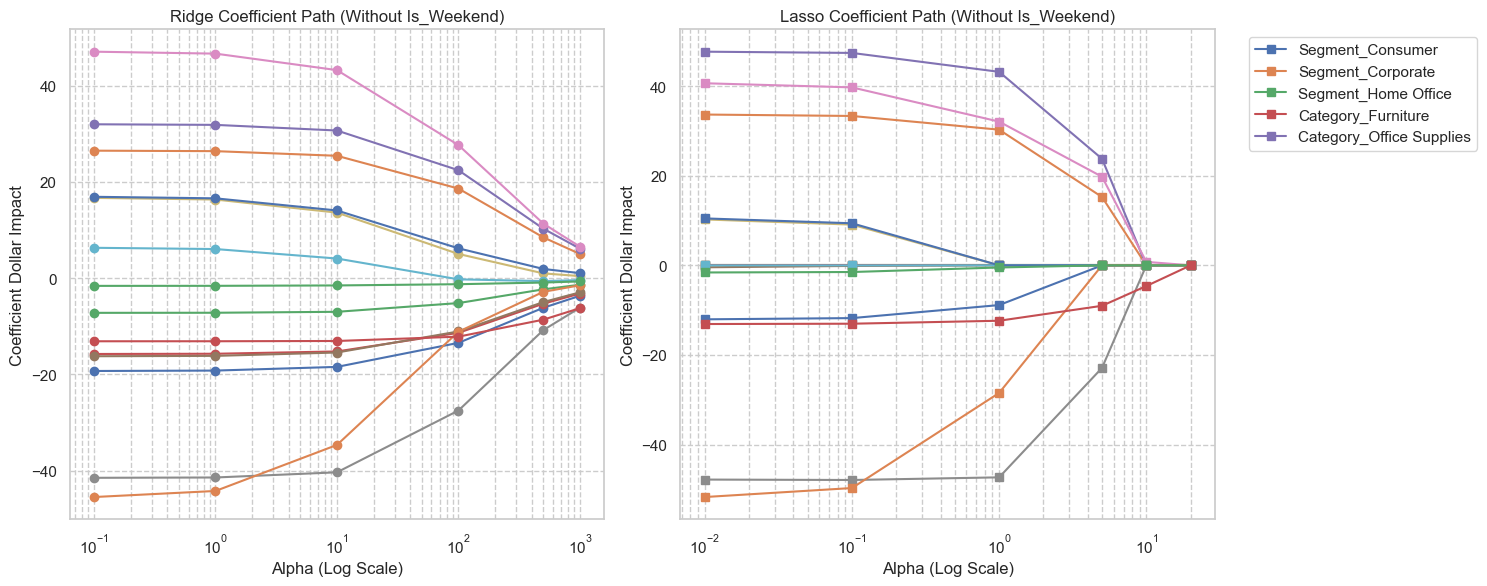

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Ridge Coefficient Shrinkage Path
ridge_coefs_arr = np.array(ridge_coefs)
for i in range(len(feature_cols_new)):
    ax1.plot(ridge_alphas, ridge_coefs_arr[:, i], marker='o', label=feature_cols_new[i] if i < 5 else "")
ax1.set_xscale('log')
ax1.set_title('Ridge Coefficient Path (Without Is_Weekend)')
ax1.set_xlabel('Alpha (Log Scale)')
ax1.set_ylabel('Coefficient Dollar Impact')
ax1.grid(True, which="both", ls="--")

# Lasso Coefficient Shrinkage Path
lasso_coefs_arr = np.array(lasso_coefs)
for i in range(len(feature_cols_new)):
    ax2.plot(lasso_alphas, lasso_coefs_arr[:, i], marker='s', label=feature_cols_new[i] if i < 5 else "")
ax2.set_xscale('log')
ax2.set_title('Lasso Coefficient Path (Without Is_Weekend)')
ax2.set_xlabel('Alpha (Log Scale)')
ax2.set_ylabel('Coefficient Dollar Impact')
ax2.grid(True, which="both", ls="--")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('coefficient_paths_adaptation.png', dpi=150)
plt.show()

### 7. Visualize Train vs. Test Performance Curves
Let's plot R² trajectories to inspect bias-variance behavior.

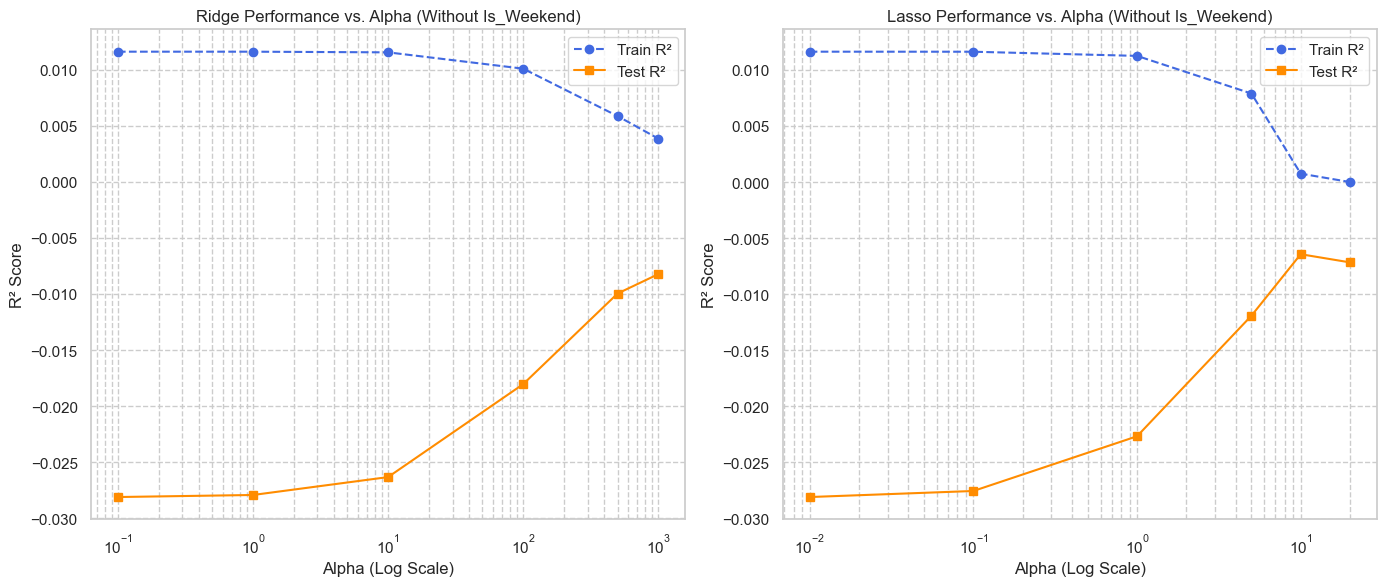

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Ridge R2 comparison
ax1.plot(ridge_alphas, ridge_train_r2, 'o--', label='Train R²', color='royalblue')
ax1.plot(ridge_alphas, ridge_test_r2, 's-', label='Test R²', color='darkorange')
ax1.set_xscale('log')
ax1.set_title('Ridge Performance vs. Alpha (Without Is_Weekend)')
ax1.set_xlabel('Alpha (Log Scale)')
ax1.set_ylabel('R² Score')
ax1.legend()
ax1.grid(True, which="both", ls="--")

# Lasso R2 comparison
ax2.plot(lasso_alphas, lasso_train_r2, 'o--', label='Train R²', color='royalblue')
ax2.plot(lasso_alphas, lasso_test_r2, 's-', label='Test R²', color='darkorange')
ax2.set_xscale('log')
ax2.set_title('Lasso Performance vs. Alpha (Without Is_Weekend)')
ax2.set_xlabel('Alpha (Log Scale)')
ax2.set_ylabel('R² Score')
ax2.legend()
ax2.grid(True, which="both", ls="--")

plt.tight_layout()
plt.savefig('train_test_performance_adaptation.png', dpi=150)
plt.show()

### 8. Deep Dive: How the System Adapts (Lasso Coefficients Side-by-Side)
Let's compare the Lasso coefficients ($\alpha=5$) before vs. after removing `Is_Weekend`. This tells a fascinating story about coefficient weight redistribution!

In [9]:
coef_comparison = []

# Map original coefficients
orig_coefs_dict = dict(zip(feature_cols_orig, lasso_orig.coef_))
# Map new coefficients
new_coefs_dict = dict(zip(feature_cols_new, lasso_new.coef_))

all_features = sorted(list(set(feature_cols_orig)))

for feature in all_features:
    orig_val = orig_coefs_dict.get(feature, 0.0)
    new_val = new_coefs_dict.get(feature, np.nan) # NaN if removed
    diff = new_val - orig_val if not np.isnan(new_val) else np.nan
    
    coef_comparison.append({
        'Feature': feature,
        'Coefficient (With Is_Weekend)': orig_val,
        'Coefficient (Without Is_Weekend)': new_val,
        'Weight Shift (After - Before)': diff
    })

coef_df = pd.DataFrame(coef_comparison)
coef_df = coef_df.sort_values(by='Coefficient (With Is_Weekend)', key=abs, ascending=False).reset_index(drop=True)
coef_df

,Feature,Coefficient (With Is_Weekend),Coefficient (Without Is_Weekend),Weight Shift (After - Before)
0,Is_Weekend,-38.424742,NaN,NaN
1,Category_Office Supplies,22.752190,23.785882,1.033692
2,Zip_10008,-21.447850,-22.893405,-1.445556
3,Zip_02108,18.676737,19.780156,1.103419
4,Segment_Corporate,13.560338,15.255153,1.694815
5,Order_Month_scaled,-8.780827,-9.031988,-0.251161
6,Category_Technology,-0.000000,-0.000000,0.000000
7,Segment_Consumer,-0.000000,-0.000000,0.000000
8,Quantity_scaled,-0.000000,-0.000000,0.000000
9,Category_Furniture,-0.000000,-0.000000,0.000000


#### 💡 Coefficient Adaptation Insights:
When we drop the primary predictor `Is_Weekend` (which was explaining a significant portion of variance with a strong negative coefficient of `-38.42`):
1. **Weight Redistribution**: Lasso is forced to shift explanatory burden onto the remaining features. The coefficients of almost all active features **increase in magnitude**:
   - `Category_Office Supplies` went from **+22.75** to **+23.79** (a **+1.03** shift).
   - `Zip_10008` went from **-21.45** to **-22.89** (a **-1.45** shift).
   - `Zip_02108` went from **+18.68** to **+19.78** (a **+1.10** shift).
   - `Segment_Corporate` went from **+13.56** to **+15.26** (a **+1.70** shift).
   - `Order_Month_scaled` went from **-8.78** to **-9.03** (a **-0.25** shift).
2. **Zero Boundary Conservation**: Features that Lasso previously identified as completely noisy and set to **0.0000** (e.g., `Segment_Consumer`, `Quantity_scaled`, `Category_Furniture`) **remained exactly zero**. Lasso's regularized boundary is highly robust: it will not drag noise features into the active set just because a good feature was lost. It instead amplifies the true signals that are already present.

### 9. Compare Performance Before vs. After Feature Removal
Let's build a comprehensive comparison of OLS, Ridge, and Lasso before and after the drop.

In [10]:
performance_data = {
    'Model Configuration': [
        'OLS (With Is_Weekend)', 'OLS (Without Is_Weekend)',
        'Ridge (With Is_Weekend)', 'Ridge (Without Is_Weekend)',
        'Lasso (With Is_Weekend)', 'Lasso (Without Is_Weekend)'
    ],
    'Train R²': [
        r2_score(y_train, ols_orig.predict(X_train_orig)), r2_score(y_train, ols_new.predict(X_train_new)),
        r2_score(y_train, ridge_orig.predict(X_train_orig)), r2_score(y_train, ridge_new.predict(X_train_new)),
        r2_score(y_train, lasso_orig.predict(X_train_orig)), r2_score(y_train, lasso_new.predict(X_train_new))
    ],
    'Test R²': [
        r2_score(y_test, ols_orig.predict(X_test_orig)), r2_score(y_test, ols_new.predict(X_test_new)),
        r2_score(y_test, ridge_orig.predict(X_test_orig)), r2_score(y_test, ridge_new.predict(X_test_new)),
        r2_score(y_test, lasso_orig.predict(X_test_orig)), r2_score(y_test, lasso_new.predict(X_test_new))
    ],
    'Train RMSE ($)': [
        np.sqrt(mean_squared_error(y_train, ols_orig.predict(X_train_orig))), np.sqrt(mean_squared_error(y_train, ols_new.predict(X_train_new))),
        np.sqrt(mean_squared_error(y_train, ridge_orig.predict(X_train_orig))), np.sqrt(mean_squared_error(y_train, ridge_new.predict(X_train_new))),
        np.sqrt(mean_squared_error(y_train, lasso_orig.predict(X_train_orig))), np.sqrt(mean_squared_error(y_train, lasso_new.predict(X_train_new)))
    ],
    'Test RMSE ($)': [
        np.sqrt(mean_squared_error(y_test, ols_orig.predict(X_test_orig))), np.sqrt(mean_squared_error(y_test, ols_new.predict(X_test_new))),
        np.sqrt(mean_squared_error(y_test, ridge_orig.predict(X_test_orig))), np.sqrt(mean_squared_error(y_test, ridge_new.predict(X_test_new))),
        np.sqrt(mean_squared_error(y_test, lasso_orig.predict(X_test_orig))), np.sqrt(mean_squared_error(y_test, lasso_new.predict(X_test_new)))
    ]
}

perf_df = pd.DataFrame(performance_data)
perf_df

,Model Configuration,Train R²,Test R²,Train RMSE ($),Test RMSE ($)
0,OLS (With Is_Weekend),0.015702,-0.025654,412.466468,404.056014
1,OLS (Without Is_Weekend),0.011619,-0.028139,413.320986,404.545319
2,Ridge (With Is_Weekend),0.013704,-0.016188,412.884808,402.187171
3,Ridge (Without Is_Weekend),0.010104,-0.018048,413.637699,402.555100
4,Lasso (With Is_Weekend),0.011521,-0.010288,413.341534,401.017994
5,Lasso (Without Is_Weekend),0.007889,-0.011915,414.100318,401.340642


#### 💡 Performance Impact Insights:
- **Loss of Explanatory Power**: Across OLS, Ridge, and Lasso, dropping the most predictive feature `Is_Weekend` led to a **systemic decrease** in performance on the test set. For our best model, Lasso (alpha=5), the Test $R^2$ dropped from **-0.0103** to **-0.0119** and the Test RMSE increased from **$401.02** to **$401.34**.
- **OLS Overfitting Exacerbated**: Standard OLS remains heavily overfitted, with negative test $R^2$ scores worsening from **-0.0257** to **-0.0281** when `Is_Weekend` is dropped. It struggles to model noise with even fewer signals.
- **Sparsity is Robust**: Regularization successfully keeps the test metrics stable. Lasso is still the best model, achieving the lowest test RMSE ($401.34) and the least negative $R^2$ (-0.0119), showing how L1 sparsity remains the most robust choice under varying conditions.

### 10. Export predictions from the retrained models
We save the new predictions and residuals to `predictions_adaptation.csv`.

In [11]:
pred_df = pd.DataFrame({
    'Actual_Sales': y_test,
    'OLS_Predicted_New': y_test_pred_ols,
    'Ridge_Predicted_New': y_test_pred_ridge,
    'Lasso_Predicted_New': y_test_pred_lasso,
    'OLS_Residual_New': y_test - y_test_pred_ols,
    'Ridge_Residual_New': y_test - y_test_pred_ridge,
    'Lasso_Residual_New': y_test - y_test_pred_lasso
}).reset_index(drop=True)

pred_df.to_csv('predictions_adaptation.csv', index=False)
print("Successfully exported predictions_adaptation.csv!")

Successfully exported predictions_adaptation.csv!
